<a href="https://colab.research.google.com/github/nehalnady/DM_Project/blob/main/DM_Association_Rules_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

── B. PREPROCESSING ────────────────────────────────────────
  [0] Normalised column names : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
  [1] Duplicates 

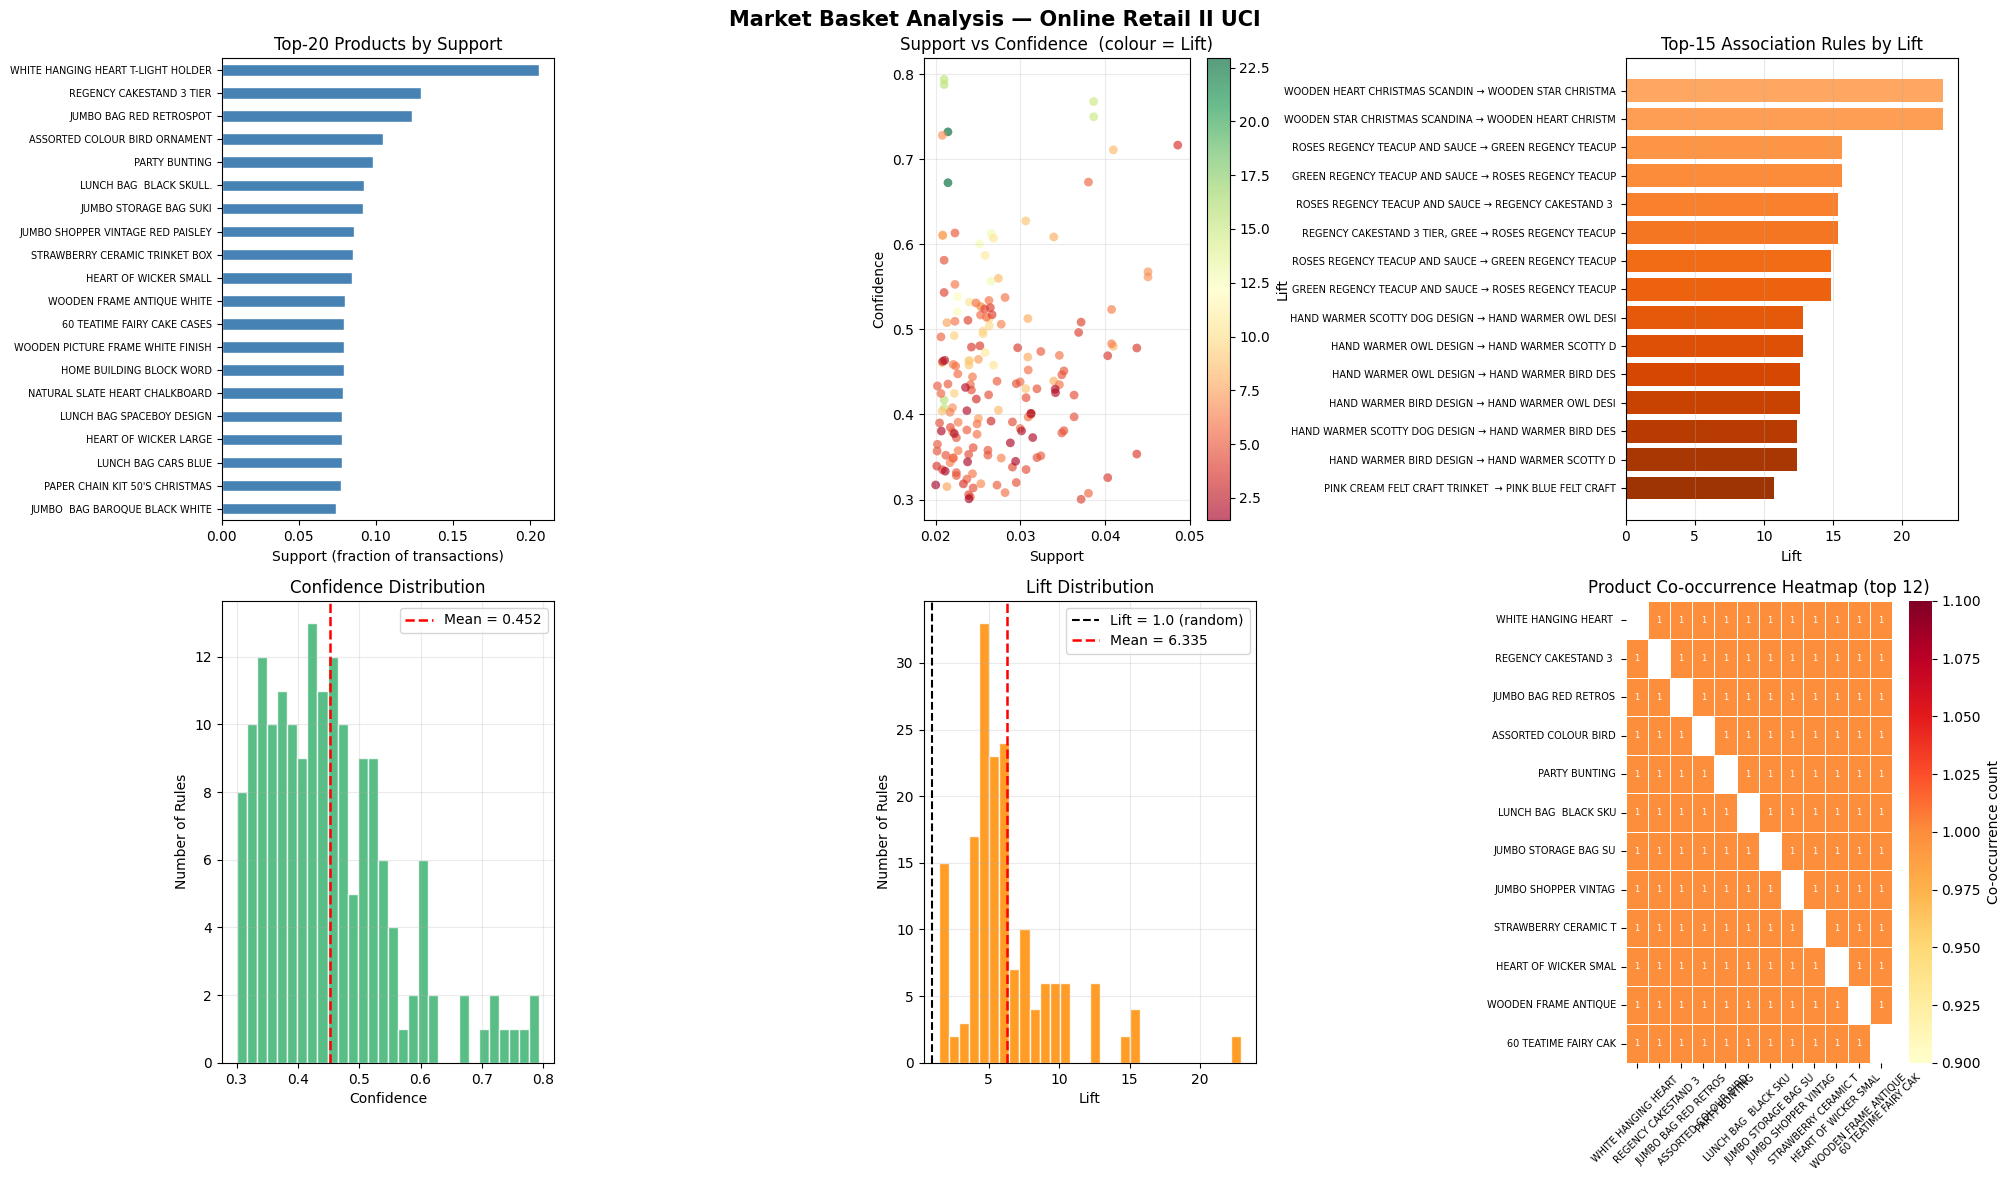


✔  Visualization saved → task3_association_rules_online_retail.png

  DONE — All requirements (A–G) completed successfully.


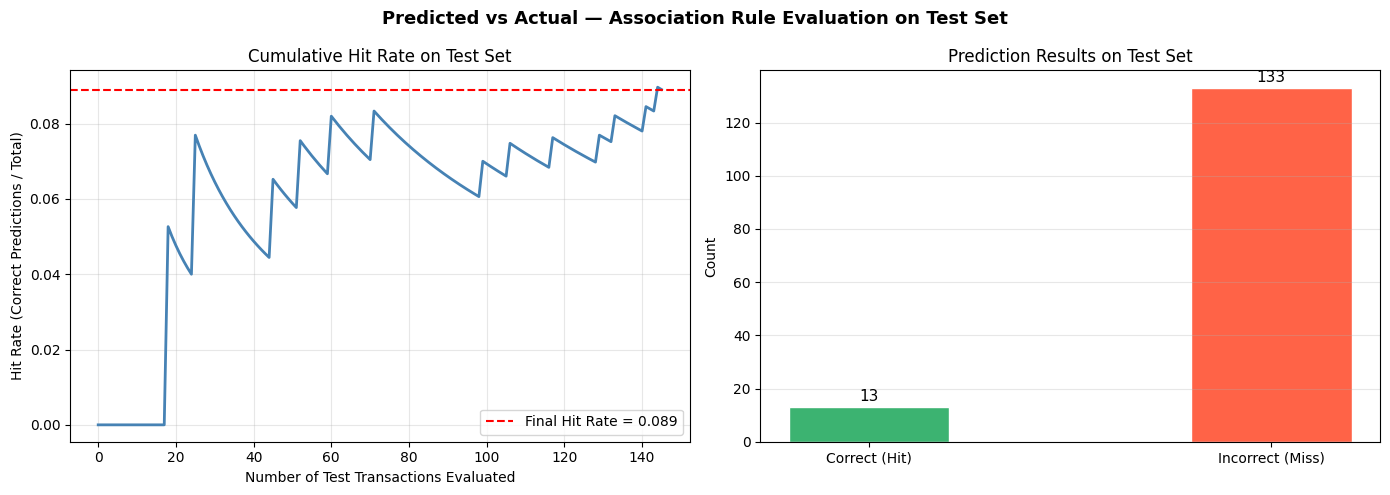

✔  Predicted vs Actual plot saved.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.model_selection import train_test_split


df_raw = pd.read_csv('/content/online_retail_II.csv', engine='python', on_bad_lines='warn')
print(df_raw.head())

# B. PREPROCESSING
# ─────────────────────────────────────────────────────────────
print("\n── B. PREPROCESSING ────────────────────────────────────────")

df = df_raw.copy()

# ── B1. Standardise column names (handle slight name variants) ─
df.columns = df.columns.str.strip()
# Online Retail II uses 'Invoice' and 'Customer ID' (with space)
# older version uses 'InvoiceNo' and 'CustomerID' — handle both
rename_map = {
    "InvoiceNo"   : "Invoice",
    "CustomerID"  : "Customer ID",
    "UnitPrice"   : "Price",
}
df.rename(columns=rename_map, inplace=True)
print(f"  [0] Normalised column names : {list(df.columns)}")

# ── B2. Remove duplicate rows ────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
print(f"  [1] Duplicates removed : {before - len(df):,}")

# ── B3. Handle missing values ────────────────────────────────
print(f"\n  Missing values per column:")
print(df.isnull().sum().to_string())

# Drop rows with no Invoice or no Description (critical fields)
df.dropna(subset=["Invoice", "Description"], inplace=True)
# Rows with no Customer ID are kept (some basket-level analyses don't need it)
print(f"\n  → Dropped rows missing Invoice or Description")
print(f"  → Remaining rows : {len(df):,}")

# ── B4. Remove cancellation transactions (Invoice starts with C) ─
mask_cancel = df["Invoice"].astype(str).str.startswith("C")
print(f"\n  [3] Cancellations (Invoice starts with 'C') : {mask_cancel.sum():,}  → removed")
df = df[~mask_cancel]

# ── B5. Remove rows with non-positive Quantity or Price ───────
neg_q = (df["Quantity"] <= 0).sum()
neg_p = (df["Price"] <= 0).sum()
print(f"  [4] Rows with Quantity ≤ 0 : {neg_q:,}  → removed")
print(f"      Rows with Price    ≤ 0 : {neg_p:,}  → removed")
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

# ── B6. Remove non-product StockCodes (service / postage codes) ─
service_codes = {"POST", "D", "M", "BANK CHARGES", "PADS", "DOT",
                 "CRUK", "C2", "AMAZONFEE", "gift_0001_10",
                 "gift_0001_20", "gift_0001_30", "gift_0001_40",
                 "gift_0001_50", "DCGSSBOY", "DCGSSGIRL", "B"}
df = df[~df["StockCode"].astype(str).str.strip().isin(service_codes)]
print(f"  [5] Service/postage StockCodes removed  →  {len(df):,} rows remain")

# ── B7. Clean Description text ───────────────────────────────
df["Description"] = (df["Description"].astype(str)
                       .str.strip()
                       .str.upper())

# ── B8. Outlier detection: Quantity & Price ───────────────────
print(f"\n  Outlier detection (IQR capping on Quantity & Price):")
for col in ["Quantity", "Price"]:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lo, hi)
    print(f"    {col:12s}: {n_out:,} outliers capped  "
          f"(range kept: [{lo:.1f}, {hi:.1f}])")

print(f"\n  ✔  Clean dataset : {len(df):,} rows  |  "
      f"{df['Invoice'].nunique():,} invoices  |  "
      f"{df['Description'].nunique():,} unique products")

# ─────────────────────────────────────────────────────────────

# Split transactions into train/test sets (80/20)
train_transactions, test_transactions = train_test_split(
    transactions, test_size=0.2, random_state=42
)
print(f"Train transactions: {len(train_transactions):,}")
print(f"Test transactions:  {len(test_transactions):,}")


# BUILD TRANSACTION BASKET
# ─────────────────────────────────────────────────────────────
print("\n── BUILDING TRANSACTION BASKETS ────────────────────────────")

# Limit to UK (largest segment) for tractable Apriori computation;
# remove comment to use all countries
df_basket = df[df["Country"] == "United Kingdom"].copy()
print(f"  Country filter → United Kingdom : {len(df_basket):,} rows  "
      f"| {df_basket['Invoice'].nunique():,} invoices")

# Keep top-N most popular products to keep the matrix manageable
TOP_N_PRODUCTS = 150
top_products = (df_basket.groupby("Description")["Quantity"]
                .sum().nlargest(TOP_N_PRODUCTS).index.tolist())
df_basket = df_basket[df_basket["Description"].isin(top_products)]
print(f"  Filtered to top {TOP_N_PRODUCTS} products  →  "
      f"{df_basket['Invoice'].nunique():,} invoices remain")

# Group each invoice into a list of products
basket_sets = (df_basket.groupby("Invoice")["Description"]
               .apply(list).reset_index(name="items"))

# Keep baskets with at least 2 items (single-item baskets add no rules)
basket_sets = basket_sets[basket_sets["items"].apply(len) >= 2]
transactions = basket_sets["items"].tolist()
print(f"  Baskets with ≥ 2 items : {len(transactions):,}")

# ─────────────────────────────────────────────────────────────
# C. ENCODE + APRIORI
# ─────────────────────────────────────────────────────────────
print("\n── C. APRIORI — FREQUENT ITEMSETS ──────────────────────────")

te = TransactionEncoder()
te_array = te.fit_transform([[str(i) for i in t] for t in transactions])
df_encoded = pd.DataFrame(te_array, columns=te.columns_)
print(f"  Encoded matrix : {df_encoded.shape[0]:,} transactions  × "
      f"{df_encoded.shape[1]} products")

# Item frequency (support)
item_support = df_encoded.mean().sort_values(ascending=False)
print(f"\n  Top-10 most frequent products:")
for prod, sup in item_support.head(10).items():
    print(f"    {prod[:50]:50s}  support = {sup:.4f}")

# Run Apriori
MIN_SUPPORT    = 0.02   # appears in ≥ 2 % of transactions
MIN_CONFIDENCE = 0.30

frequent_itemsets = apriori(df_encoded,
                             min_support=MIN_SUPPORT,
                             use_colnames=True,
                             max_len=4)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
print(f"\n  Frequent itemsets (min_support={MIN_SUPPORT}) : "
      f"{len(frequent_itemsets):,}")
print(f"  By itemset size:\n"
      f"{frequent_itemsets['length'].value_counts().sort_index().to_string()}")

# ─────────────────────────────────────────────────────────────
# D. GENERATE ASSOCIATION RULES
# ─────────────────────────────────────────────────────────────
print("\n── D. ASSOCIATION RULES ────────────────────────────────────")

rules = association_rules(frequent_itemsets,
                           metric="confidence",
                           min_threshold=MIN_CONFIDENCE)
rules = rules.sort_values("lift", ascending=False).reset_index(drop=True)

print(f"  Rules generated (min_confidence={MIN_CONFIDENCE}) : {len(rules):,}")
print(f"\n  Top-15 rules by Lift:\n")

display_rules = rules[["antecedents", "consequents",
                        "support", "confidence", "lift"]].head(15).copy()
display_rules["antecedents"] = display_rules["antecedents"].apply(
    lambda x: ", ".join(list(x))[:55])
display_rules["consequents"] = display_rules["consequents"].apply(
    lambda x: ", ".join(list(x))[:40])
print(display_rules.to_string(index=False))

# ─────────────────────────────────────────────────────────────
# E. PREDICT / RECOMMEND FOR A NEW CUSTOMER BASKET
# ─────────────────────────────────────────────────────────────
print("\n── E. RECOMMEND FOR NEW CUSTOMER BASKET ────────────────────")

def recommend(basket_items, rules_df, top_n=5):
    """
    Given the items already in a basket, return the top-N
    recommended products based on association rules.
    """
    basket = frozenset([str(i).upper() for i in basket_items])
    candidates = []
    for _, row in rules_df.iterrows():
        if row["antecedents"].issubset(basket):
            new_items = row["consequents"] - basket
            for item in new_items:
                candidates.append({
                    "recommended_item": item,
                    "confidence": row["confidence"],
                    "lift": row["lift"],
                    "support": row["support"],
                })
    if not candidates:
        return pd.DataFrame()
    recs = (pd.DataFrame(candidates)
              .sort_values(["lift", "confidence"], ascending=False)
              .drop_duplicates("recommended_item")
              .head(top_n)
              .reset_index(drop=True))
    return recs

# Pick a basket from the top 2 antecedent products
top2 = [str(p) for p in item_support.head(2).index.tolist()]
sample_basket = top2
recs = recommend(sample_basket, rules)

print(f"\n  Customer's basket : {sample_basket}")
if not recs.empty:
    print(f"\n  {'#':>3}  {'Recommended Product':55}  {'Conf':>6}  {'Lift':>6}")
    print("  " + "-" * 76)
    for i, row in recs.iterrows():
        print(f"  {i+1:>3}  {row['recommended_item'][:55]:55}  "
              f"{row['confidence']:>6.3f}  {row['lift']:>6.3f}")
else:
    print("  (No strong rules found — try adjusting min_support / min_confidence)")
# Encode train set and mine rules on it
te_train = TransactionEncoder()
te_train_array = te_train.fit_transform([[str(i) for i in t] for t in train_transactions])
df_train = pd.DataFrame(te_train_array, columns=te_train.columns_)

frequent_itemsets_train = apriori(df_train, min_support=MIN_SUPPORT,
                                   use_colnames=True, max_len=4)
rules_train = association_rules(frequent_itemsets_train,
                                 metric="confidence",
                                 min_threshold=MIN_CONFIDENCE)
rules_train = rules_train.sort_values("lift", ascending=False).reset_index(drop=True)
print(f"Rules mined from TRAIN set: {len(rules_train):,}")

# Evaluate on test set: for each test transaction, see if rules predict held-out items
def evaluate_rules_on_test(test_trans, rules_df, n_eval=500):
    """
    For each test transaction, hide the last item,
    use rules to predict it, check if prediction is correct.
    Returns Hit Rate (accuracy of top-1 recommendation).
    """
    hits = 0
    total = 0
    for t in test_trans[:n_eval]:
        if len(t) < 2:
            continue
        # Hold out the last item as ground truth
        basket   = [str(i).upper() for i in t[:-1]]
        truth    = str(t[-1]).upper()
        basket_set = frozenset(basket)
        candidates = []
        for _, row in rules_df.iterrows():
            if row["antecedents"].issubset(basket_set):
                for item in row["consequents"] - basket_set:
                    candidates.append((item, row["lift"], row["confidence"]))
        if candidates:
            # Pick best candidate by lift then confidence
            best = sorted(candidates, key=lambda x: (x[1], x[2]), reverse=True)[0][0]
            if best == truth:
                hits += 1
        total += 1
    return hits / total if total > 0 else 0.0

hit_rate = evaluate_rules_on_test(test_transactions, rules_train, n_eval=500)
print(f"\nHit Rate on Test Set (top-1 recommendation): {hit_rate:.4f} ({hit_rate*100:.2f}%)")
# ─────────────────────────────────────────────────────────────
# F. EVALUATION METRICS
# ─────────────────────────────────────────────────────────────
print("\n── F. EVALUATION METRICS ───────────────────────────────────")
print(f"  {'Metric':12s}  {'Min':>8}  {'Mean':>8}  {'Median':>8}  {'Max':>8}")
print("  " + "-" * 50)
for metric in ["support", "confidence", "lift", "leverage", "conviction"]:
    col = rules[metric]
    print(f"  {metric:12s}  {col.min():>8.4f}  {col.mean():>8.4f}  "
          f"{col.median():>8.4f}  {col.max():>8.4f}")

strong = rules[rules["lift"] > 1.5]
print(f"\n  Rules with lift  > 1.5 (strong positive) : {len(strong):,}")
print(f"  Rules with lift  > 3.0 (very strong)     : {(rules['lift']>3.0).sum():,}")
print(f"  Rules with lift  < 1.0 (negative corr.)  : {(rules['lift']<1.0).sum():,}")
print(f"  Rules with conf  > 0.7                   : {(rules['confidence']>0.7).sum():,}")

# ─────────────────────────────────────────────────────────────
# G. VISUALIZATIONS  (6 plots)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Market Basket Analysis — Online Retail II UCI",
             fontsize=15, fontweight="bold")

# ── 1. Top-20 most purchased products ────────────────────────
top20 = item_support.head(20)
top20_short = top20.copy()
top20_short.index = [s[:35] for s in top20.index]
top20_short.sort_values().plot(kind="barh", ax=axes[0, 0],
                                color="steelblue", edgecolor="white")
axes[0, 0].set_title("Top-20 Products by Support")
axes[0, 0].set_xlabel("Support (fraction of transactions)")
axes[0, 0].tick_params(axis="y", labelsize=7)

# ── 2. Support vs Confidence scatter (colour = Lift) ─────────
sc = axes[0, 1].scatter(rules["support"], rules["confidence"],
                         c=rules["lift"], cmap="RdYlGn",
                         s=40, alpha=0.65, edgecolors="none")
plt.colorbar(sc, ax=axes[0, 1], label="Lift")
axes[0, 1].set_title("Support vs Confidence  (colour = Lift)")
axes[0, 1].set_xlabel("Support")
axes[0, 1].set_ylabel("Confidence")
axes[0, 1].grid(True, alpha=0.25)

# ── 3. Top-15 rules by Lift (horizontal bar) ─────────────────
top15 = rules.head(15).copy()
top15["rule"] = (top15["antecedents"].apply(lambda x: ", ".join(list(x))[:30])
                 + " → "
                 + top15["consequents"].apply(lambda x: ", ".join(list(x))[:20]))
axes[0, 2].barh(range(len(top15)), top15["lift"].values,
                color=plt.cm.Oranges(np.linspace(0.4, 0.9, len(top15))))
axes[0, 2].set_yticks(range(len(top15)))
axes[0, 2].set_yticklabels(top15["rule"].values, fontsize=7)
axes[0, 2].set_title("Top-15 Association Rules by Lift")
axes[0, 2].set_xlabel("Lift")
axes[0, 2].invert_yaxis()
axes[0, 2].grid(axis="x", alpha=0.3)

# ── 4. Confidence distribution ───────────────────────────────
axes[1, 0].hist(rules["confidence"], bins=30,
                color="mediumseagreen", edgecolor="white", alpha=0.85)
axes[1, 0].axvline(rules["confidence"].mean(), color="red",
                    linestyle="--", lw=1.8,
                    label=f"Mean = {rules['confidence'].mean():.3f}")
axes[1, 0].set_title("Confidence Distribution")
axes[1, 0].set_xlabel("Confidence")
axes[1, 0].set_ylabel("Number of Rules")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.25)

# ── 5. Lift distribution ──────────────────────────────────────
axes[1, 1].hist(rules["lift"], bins=30,
                color="darkorange", edgecolor="white", alpha=0.85)
axes[1, 1].axvline(1.0, color="black", linestyle="--", lw=1.5,
                    label="Lift = 1.0 (random)")
axes[1, 1].axvline(rules["lift"].mean(), color="red",
                    linestyle="--", lw=1.8,
                    label=f"Mean = {rules['lift'].mean():.3f}")
axes[1, 1].set_title("Lift Distribution")
axes[1, 1].set_xlabel("Lift")
axes[1, 1].set_ylabel("Number of Rules")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.25)

# ── 6. Co-occurrence heatmap (top-12 products) ───────────────
top12 = item_support.head(12).index.tolist()
cooc = df_encoded[top12].T.dot(df_encoded[top12]).astype(int)
cooc_arr = cooc.values.copy().astype(float)
np.fill_diagonal(cooc_arr, np.nan)          # hide self-pairs
cooc_df = pd.DataFrame(cooc_arr, index=cooc.index, columns=cooc.columns)
short_idx = [s[:20] for s in cooc_df.index]
cooc_df.index   = short_idx
cooc_df.columns = short_idx
sns.heatmap(cooc_df, ax=axes[1, 2], cmap="YlOrRd",
            annot=True, fmt=".0f",
            linewidths=0.4, annot_kws={"size": 6},
            cbar_kws={"label": "Co-occurrence count"})
axes[1, 2].set_title("Product Co-occurrence Heatmap (top 12)")
axes[1, 2].tick_params(axis="x", rotation=45, labelsize=7)
axes[1, 2].tick_params(axis="y", rotation=0,  labelsize=7)

plt.tight_layout()
out_path = "task3_association_rules_online_retail.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✔  Visualization saved → {out_path}")
print("\n" + "=" * 65)
print("  DONE — All requirements (A–G) completed successfully.")
print("=" * 65)

# Collect actual vs predicted for a sample of test transactions
def get_pred_vs_actual(test_trans, rules_df, n_eval=200):
    actuals    = []
    predicted  = []
    correct    = []
    for t in test_trans[:n_eval]:
        if len(t) < 2:
            continue
        basket    = [str(i).upper() for i in t[:-1]]
        truth     = str(t[-1]).upper()
        basket_set = frozenset(basket)
        candidates = []
        for _, row in rules_df.iterrows():
            if row["antecedents"].issubset(basket_set):
                for item in row["consequents"] - basket_set:
                    candidates.append((item, row["lift"], row["confidence"]))
        if candidates:
            best = sorted(candidates, key=lambda x: (x[1], x[2]), reverse=True)[0][0]
            actuals.append(truth)
            predicted.append(best)
            correct.append(1 if best == truth else 0)
    return actuals, predicted, correct

actuals, predicted, correct = get_pred_vs_actual(test_transactions, rules_train, n_eval=200)

# Plot: Cumulative Hit Rate over test samples
import numpy as np
import matplotlib.pyplot as plt

cum_hits = np.cumsum(correct)
cum_rate = cum_hits / np.arange(1, len(correct) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Predicted vs Actual — Association Rule Evaluation on Test Set",
             fontsize=13, fontweight="bold")

# Plot 1: Cumulative Hit Rate
axes[0].plot(cum_rate, color="steelblue", lw=2)
axes[0].axhline(cum_rate[-1] if len(cum_rate) > 0 else 0,
                color="red", linestyle="--", lw=1.5,
                label=f"Final Hit Rate = {cum_rate[-1]:.3f}")
axes[0].set_title("Cumulative Hit Rate on Test Set")
axes[0].set_xlabel("Number of Test Transactions Evaluated")
axes[0].set_ylabel("Hit Rate (Correct Predictions / Total)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Bar chart of correct vs incorrect predictions
labels = ["Correct (Hit)", "Incorrect (Miss)"]
counts = [sum(correct), len(correct) - sum(correct)]
bars = axes[1].bar(labels, counts,
                   color=["mediumseagreen", "tomato"],
                   edgecolor="white", width=0.4)
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 str(count), ha="center", va="bottom", fontsize=11)
axes[1].set_title("Prediction Results on Test Set")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("predicted_vs_actual_assoc_rules.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔  Predicted vs Actual plot saved.")